# Real-Data Cache Policy Replay Comparison

This notebook is a runnable demo of `method.py`, which asks: **does a simple, well-specified cache-refresh policy measurably reduce redundant LLM tool calls, and what does it cost in staleness?**

It loads a real-content corpus of versioned "resources" (tool-call results whose ground-truth content changes over time on `static` / `periodic` / `bursty` schedules), reconstructs the original per-episode call streams, and replays **six cache policies** against those streams:

- **FixedTTL** — naive fixed time-to-live baseline
- **d-TTL** — literal Robbins-Monro stochastic-approximation TTL targeting a hit rate
- **EWMA-adaptive TTL** — TTL driven by an exponentially-weighted moving average of observed staleness
- **FreshCache (raw)** — per-call-site exponential-hazard gate on reuse probability
- **FreshCache (pooled)** — same hazard gate, but hazard stats pooled across a resource's *class* (fixes small-sample calibration)
- **AIMD** — additive-increase/multiplicative-decrease window adaptation

All six share one `PolicyBase.decide/update` interface keyed by `call_site_signature`, so the only difference between them is the adaptation rule -- eliminating implementation confounds. Staleness feedback is only revealed when a call is refreshed or hits a randomly-drawn spot-check, mimicking a realistic partial-observability setting.

This demo uses a small curated subset of the real corpus (`mini_demo_data.json`, 100 rows from one episode spanning all three volatility regimes) so it runs in seconds, plus the full synthetic Zipf-popularity simulator run side-by-side exactly as in the original script.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- not pre-installed on Colab, always install
_pip('loguru==0.7.3')

# matplotlib -- pre-installed on Colab, install locally only (to match Colab's exact version)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import random
import sys
from collections import defaultdict

from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a08cec-does-tcp-style-reactive-caching-actually/main/round-2/experiment-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {sum(len(ds['examples']) for ds in data['datasets'])} rows from {len(data['datasets'])} dataset(s)")

Loaded 100 rows from 1 dataset(s)


## Configuration

All tunable parameters are gathered here. `N_REPLICATES` controls how many random seeds each (policy, knob, spot-check-rate) cell is replayed with (the original defaults to 20 for a full run); `MAX_CELLS` caps how many distinct (policy, knob, spot_rate) cells actually get replayed, keeping this demo fast. Both are set to the smallest values that still produce a meaningful comparison across all six policies; increase them to scale up towards the original full-run values (commented below).

In [5]:
# N_REPLICATES = 20  # original full-run value
N_REPLICATES = 2       # replicate seeds per (policy, knob, spot_check_rate) cell -- minimal demo value

MAX_CELLS = None       # cap on number of distinct (policy, knob, spot_rate) cells to run (None = no cap)

SPOT_CHECK_RATES = [0.10, 0.20, 0.40]   # spot-check ablation grid (unchanged from original)
HEADLINE_RATE = 0.20                     # headline spot-check rate swept for every policy

SYNTH_SEED = 12345
SYNTH_N_EPISODES = 30   # synthetic Zipf simulator episode count (unchanged from original -- already fast)
SYNTH_SIM_DAYS = 30

## 0. Parse rows into per-episode call streams

The real corpus is a flat list of rows, each row a single tool-call event whose `input` (JSON string) carries the episode/call/resource identifiers and whose `metadata_version_schedule` carries that resource's full version history. `parse_rows_into_episodes` groups rows back into per-episode, time-ordered call streams and per-resource version schedules -- this is exactly the logic `method.py` runs after its fail-fast dependency loader confirms the corpus file is present and non-truncated (the loud fail-fast check itself is omitted here since `data` is already loaded from `mini_demo_data.json` above).

In [6]:
def parse_rows_into_episodes(rows):
    episodes = defaultdict(list)
    resource_schedules = {}
    regime_counts = defaultdict(int)
    malformed = 0
    for r in rows:
        try:
            inp = json.loads(r["input"])
            sched = json.loads(r["metadata_version_schedule"])
        except (json.JSONDecodeError, KeyError):
            malformed += 1
            continue
        resource_schedules[inp["resource_id"]] = sched
        regime = r["metadata_volatility_regime"]
        regime_counts[regime] += 1
        episodes[inp["episode_id"]].append(
            {
                "call_index": inp["call_index"],
                "timestamp_tick": inp["timestamp_tick"],
                "call_site_signature": inp["call_site_signature"],
                "resource_id": inp["resource_id"],
                "ground_truth_version_id": r["output"],
                "volatility_regime": regime,
                "resource_class": r["metadata_resource_class"],
            }
        )
    frac_malformed = malformed / max(1, len(rows))
    if frac_malformed > 0.01:
        logger.warning(
            f"{malformed}/{len(rows)} ({frac_malformed:.1%}) rows failed to parse -- "
            f"exceeds 1% threshold, but continuing with the rows that did parse."
        )
    for ep in episodes:
        episodes[ep].sort(key=lambda c: (c["timestamp_tick"], c["call_index"]))
    logger.info(f"Parsed {len(episodes)} episodes, {len(resource_schedules)} resources")
    logger.info(f"Volatility regime distribution: {dict(regime_counts)}")
    missing_regimes = {"static", "periodic", "bursty"} - set(regime_counts)
    if missing_regimes:
        logger.warning(f"Missing volatility regimes in parsed data: {missing_regimes}")
    return dict(episodes), resource_schedules


rows_raw = [ex for ds in data["datasets"] for ex in ds["examples"]]
episodes_real, resource_schedules_real = parse_rows_into_episodes(rows_raw)

06:16:08|INFO   |Parsed 1 episodes, 27 resources


06:16:08|INFO   |Volatility regime distribution: {'static': 79, 'periodic': 18, 'bursty': 3}


## 1. Synthetic Zipf-popularity simulator

As a second, explicitly-labeled `data_source` (never a silent fallback for the real corpus), the original script also builds a synthetic corpus: resources with `static`/`periodic`/`bursty` version schedules, and episodes that draw resources with Zipf(s=1.2) popularity weights. This is run side-by-side with the real corpus so the comparison isn't purely single-source.

In [7]:
def build_synthetic_zipf_episodes(seed: int = 12345, n_episodes: int = 30, sim_days: int = 30):
    rng = random.Random(seed)
    n_resources_per_regime = {"static": 90, "periodic": 60, "bursty": 20}
    resource_schedules = {}
    resource_meta = {}
    rid_counter = 0
    for regime, n_res in n_resources_per_regime.items():
        for _ in range(n_res):
            rid = f"synth_{regime}_{rid_counter:04d}"
            rid_counter += 1
            if regime == "static":
                sched = [
                    {
                        "version_id": f"{rid}_v0",
                        "content_hash": "synthetic",
                        "valid_from_tick": 0,
                        "valid_until_tick": sim_days - 1,
                    }
                ]
            elif regime == "periodic":
                period = rng.choice([3, 5, 7])
                sched = []
                t = 0
                v = 0
                while t <= sim_days - 1:
                    nxt = min(sim_days - 1, t + period - 1)
                    sched.append(
                        {
                            "version_id": f"{rid}_v{v}",
                            "content_hash": "synthetic",
                            "valid_from_tick": t,
                            "valid_until_tick": nxt,
                        }
                    )
                    t = nxt + 1
                    v += 1
            else:  # bursty: heavy-tailed irregular intervals (Pareto-ish via exponential mix)
                sched = []
                t = 0
                v = 0
                while t <= sim_days - 1:
                    gap = max(1, int(rng.expovariate(1 / 2.0)))
                    nxt = min(sim_days - 1, t + gap - 1)
                    sched.append(
                        {
                            "version_id": f"{rid}_v{v}",
                            "content_hash": "synthetic",
                            "valid_from_tick": t,
                            "valid_until_tick": nxt,
                        }
                    )
                    t = nxt + 1
                    v += 1
            resource_schedules[rid] = sched
            resource_meta[rid] = regime
    resource_ids = list(resource_schedules.keys())

    def version_at(rid, tick):
        for entry in resource_schedules[rid]:
            if entry["valid_from_tick"] <= tick <= entry["valid_until_tick"]:
                return entry["version_id"]
        return resource_schedules[rid][-1]["version_id"]

    # Zipf popularity ranking over resources -> episodes draw with Zipf(s=1.2) weights
    ranks = list(range(1, len(resource_ids) + 1))
    weights = [1.0 / (r ** 1.2) for r in ranks]
    total_w = sum(weights)
    probs = [w / total_w for w in weights]

    episodes = defaultdict(list)
    for ep_i in range(n_episodes):
        ep_id = f"synth_ep_{ep_i:03d}"
        n_resources_in_ep = rng.randint(10, 20)
        chosen = rng.choices(resource_ids, weights=probs, k=n_resources_in_ep)
        chosen = list(dict.fromkeys(chosen))  # dedupe preserving order/popularity draw
        call_idx = 0
        for rid in chosen:
            n_reuse = rng.randint(3, 8)
            tick = rng.randint(0, 3)
            for _ in range(n_reuse):
                sig = f"tool_call({rid})"
                episodes[ep_id].append(
                    {
                        "call_index": call_idx,
                        "timestamp_tick": min(sim_days - 1, tick),
                        "call_site_signature": sig,
                        "resource_id": rid,
                        "ground_truth_version_id": version_at(rid, min(sim_days - 1, tick)),
                        "volatility_regime": resource_meta[rid],
                        "resource_class": "synthetic",
                    }
                )
                call_idx += 1
                tick += rng.choice([1, 3, 7, 14])
        episodes[ep_id].sort(key=lambda c: (c["timestamp_tick"], c["call_index"]))
    logger.info(
        f"Built synthetic Zipf corpus: {len(episodes)} episodes, "
        f"{sum(len(v) for v in episodes.values())} calls, {len(resource_ids)} resources"
    )
    return dict(episodes), resource_schedules


episodes_synth, resource_schedules_synth = build_synthetic_zipf_episodes(
    seed=SYNTH_SEED, n_episodes=SYNTH_N_EPISODES, sim_days=SYNTH_SIM_DAYS
)

06:16:08|INFO   |Built synthetic Zipf corpus: 30 episodes, 1626 calls, 170 resources


## 2. Cache policy implementations

Six policies, one shared `PolicyBase.decide/update` interface keyed by `call_site_signature`. `decide` returns `serve_cache` or `refresh`; `update` is called after every call with whether it was served from cache, whether staleness was observed (`None` if unobserved), and whether it was spot-checked.

In [8]:
class PolicyBase:
    name = "base"

    def __init__(self, knob):
        self.knob = knob
        self.cache = {}  # key -> {"version": str, "last_fetch_tick": int}

    def decide(self, call, now_tick):
        key = call["call_site_signature"]
        entry = self.cache.get(key)
        if entry is None:
            return "refresh", None
        if self._is_stale_by_policy(key, entry, now_tick):
            return "refresh", entry["version"]
        return "serve_cache", entry["version"]

    def _is_stale_by_policy(self, key, entry, now_tick):
        raise NotImplementedError

    def update(self, call, served_from_cache, observed_stale, spot_checked):
        key = call["call_site_signature"]
        if not served_from_cache:
            self.cache[key] = {"version": call["ground_truth_version_id"], "last_fetch_tick": call["timestamp_tick"]}

    def current_param(self, key):
        raise NotImplementedError


class FixedTTL(PolicyBase):
    name = "fixed_ttl"

    def _is_stale_by_policy(self, key, entry, now_tick):
        return (now_tick - entry["last_fetch_tick"]) >= self.knob

    def current_param(self, key):
        return self.knob


class DTTL(PolicyBase):
    """Literal reimplementation of stochastic-approximation TTL-toward-target-hit-rate
    (Basu et al.-style Robbins-Monro update): ttl += eta*(hit_observed - target_hit_rate)/k."""

    name = "d_ttl"
    ETA = 6.0
    TTL_MIN, TTL_MAX = 1.0, 60.0

    def __init__(self, knob):
        super().__init__(knob)
        self.ttl = defaultdict(lambda: 3.0)
        self.k = defaultdict(int)

    def _is_stale_by_policy(self, key, entry, now_tick):
        return (now_tick - entry["last_fetch_tick"]) >= self.ttl[key]

    def update(self, call, served_from_cache, observed_stale, spot_checked):
        key = call["call_site_signature"]
        self.k[key] += 1
        hit_observed = 1.0 if served_from_cache else 0.0
        step = self.ETA * (hit_observed - self.knob) / self.k[key]
        self.ttl[key] = min(self.TTL_MAX, max(self.TTL_MIN, self.ttl[key] + step))
        super().update(call, served_from_cache, observed_stale, spot_checked)

    def current_param(self, key):
        return self.ttl[key]


class EWMAAdaptive(PolicyBase):
    """EWMA of confirmed-stale rate drives TTL up/down toward a target tolerable staleness."""

    name = "ewma_adaptive"
    TARGET_STALE = 0.05
    GAIN = 1.5
    TTL_MIN, TTL_MAX = 1.0, 60.0

    def __init__(self, knob):
        super().__init__(knob)
        self.ttl = defaultdict(lambda: 3.0)
        self.ewma = defaultdict(float)

    def _is_stale_by_policy(self, key, entry, now_tick):
        return (now_tick - entry["last_fetch_tick"]) >= self.ttl[key]

    def update(self, call, served_from_cache, observed_stale, spot_checked):
        key = call["call_site_signature"]
        if observed_stale is not None:
            obs = 1.0 if observed_stale else 0.0
            self.ewma[key] = self.knob * obs + (1 - self.knob) * self.ewma[key]
            factor = 1 + self.GAIN * (self.TARGET_STALE - self.ewma[key])
            self.ttl[key] = min(self.TTL_MAX, max(self.TTL_MIN, self.ttl[key] * factor))
        super().update(call, served_from_cache, observed_stale, spot_checked)

    def current_param(self, key):
        return self.ttl[key]


class FreshCacheGate(PolicyBase):
    """Exponential-decay hazard model fit from accumulated spot-check labels, gating reuse
    against an error_budget. `pooled=True` shares hazard statistics across all call-sites of
    the same resource_class (fixes small-sample calibration on low-repeat sites)."""

    name = "freshcache_raw"
    pooled = False
    PRIOR_LAMBDA = 0.02

    def __init__(self, knob):
        super().__init__(knob)
        self.stale_events = defaultdict(float)
        self.total_age_ticks = defaultdict(float)

    def _group_key(self, call):
        return call["resource_class"] if self.pooled else call["call_site_signature"]

    def decide(self, call, now_tick):
        key = call["call_site_signature"]
        entry = self.cache.get(key)
        if entry is None:
            return "refresh", None
        age = now_tick - entry["last_fetch_tick"]
        gkey = self._group_key(call)
        lam = (self.stale_events[gkey] + 1e-6) / (self.total_age_ticks[gkey] + 1e-6 / self.PRIOR_LAMBDA)
        prob_stale = 1 - pow(2.718281828, -lam * max(age, 0))
        if prob_stale > self.knob:
            return "refresh", entry["version"]
        return "serve_cache", entry["version"]

    def _is_stale_by_policy(self, key, entry, now_tick):
        raise NotImplementedError

    def update(self, call, served_from_cache, observed_stale, spot_checked):
        key = call["call_site_signature"]
        if observed_stale is not None:
            gkey = self._group_key(call)
            entry = self.cache.get(key)
            age = (call["timestamp_tick"] - entry["last_fetch_tick"]) if entry else 0
            self.total_age_ticks[gkey] += max(age, 1e-3)
            if observed_stale:
                self.stale_events[gkey] += 1.0
        super().update(call, served_from_cache, observed_stale, spot_checked)

    def current_param(self, key):
        gkey = key
        return (self.stale_events[gkey] + 1e-6) / (self.total_age_ticks[gkey] + 1e-6 / self.PRIOR_LAMBDA)

    def current_hazard(self, key):
        return self.current_param(key)


class FreshCacheGateRaw(FreshCacheGate):
    name = "freshcache_raw"
    pooled = False


class FreshCacheGatePooled(FreshCacheGate):
    name = "freshcache_pooled"
    pooled = True

    def current_param(self, key):
        return None  # pooled stat is per resource_class, not per call-site; reported separately


class AIMD(PolicyBase):
    """Additive-increase/multiplicative-decrease window per call_site_signature."""

    name = "aimd"
    W_MIN, W_MAX = 1.0, 60.0
    W_INIT = 3.0

    def __init__(self, knob):
        super().__init__(knob)
        self.a, self.b = knob
        self.window = defaultdict(lambda: self.W_INIT)

    def _is_stale_by_policy(self, key, entry, now_tick):
        return (now_tick - entry["last_fetch_tick"]) >= self.window[key]

    def update(self, call, served_from_cache, observed_stale, spot_checked):
        key = call["call_site_signature"]
        if observed_stale is not None:
            if observed_stale:
                self.window[key] = max(self.W_MIN, self.window[key] * self.b)
            else:
                self.window[key] = min(self.W_MAX, self.window[key] + self.a)
        super().update(call, served_from_cache, observed_stale, spot_checked)

    def current_param(self, key):
        return self.window[key]


POLICIES = {
    "fixed_ttl": (FixedTTL, [1, 3, 7, 14, 30]),
    "d_ttl": (DTTL, [0.5, 0.7, 0.9]),
    "ewma_adaptive": (EWMAAdaptive, [0.1, 0.3, 0.5]),
    "freshcache_raw": (FreshCacheGateRaw, [0.10, 0.20, 0.35]),
    "freshcache_pooled": (FreshCacheGatePooled, [0.10, 0.20, 0.35]),
    "aimd": (AIMD, [(a, b) for a in [0.1, 0.25, 0.5] for b in [0.5, 0.7, 0.9]]),
}

## 3. Replay engine

Shared across both data sources: replay one policy instance against one episode set, aggregating hit-rate / staleness metrics into a single replicate row. Staleness is only *observed* (fed back to the policy) when a call is refreshed or hits a randomly-drawn spot-check -- `ground_truth_stale` is always computed for scoring, but `observed_stale` (what the policy sees) is `None` otherwise.

In [9]:
def replay_aggregate(episodes, policy_factory, knob, spot_check_rate, seed):
    rng = random.Random(seed)
    policy = policy_factory(knob)

    n_calls = 0
    n_served = 0
    n_stale_served = 0
    n_spot_checked = 0
    param_sum = 0.0
    param_n = 0
    regime_stats = defaultdict(lambda: {"n": 0, "served": 0, "stale": 0})

    for episode_id, calls in episodes.items():
        for call in calls:
            now_tick = call["timestamp_tick"]
            decision, cached_version = policy.decide(call, now_tick)
            served_from_cache = decision == "serve_cache"
            spot_checked = rng.random() < spot_check_rate
            true_version = call["ground_truth_version_id"]
            ground_truth_stale = served_from_cache and (cached_version != true_version)
            observed_stale = ground_truth_stale if (spot_checked or not served_from_cache) else None

            n_calls += 1
            regime = call["volatility_regime"]
            regime_stats[regime]["n"] += 1
            if served_from_cache:
                n_served += 1
                regime_stats[regime]["served"] += 1
                if ground_truth_stale:
                    n_stale_served += 1
                    regime_stats[regime]["stale"] += 1
            if spot_checked:
                n_spot_checked += 1

            try:
                p = policy.current_param(call["call_site_signature"])
                if p is not None:
                    param_sum += p
                    param_n += 1
            except NotImplementedError:
                pass

            policy.update(call, served_from_cache, observed_stale, spot_checked)

    hit_rate = n_served / n_calls if n_calls else 0.0
    stale_rate_of_served = n_stale_served / n_served if n_served else 0.0
    stale_rate_of_calls = n_stale_served / n_calls if n_calls else 0.0
    mean_adapted_param = param_sum / param_n if param_n else None

    regime_breakdown = {}
    for regime, s in regime_stats.items():
        regime_breakdown[regime] = {
            "n": s["n"],
            "hit_rate": s["served"] / s["n"] if s["n"] else 0.0,
            "stale_rate_of_served": s["stale"] / s["served"] if s["served"] else 0.0,
        }

    return {
        "n_calls": n_calls,
        "n_served_from_cache": n_served,
        "n_stale_served": n_stale_served,
        "n_spot_checked": n_spot_checked,
        "hit_rate": hit_rate,
        "stale_rate_of_served": stale_rate_of_served,
        "stale_rate_of_calls": stale_rate_of_calls,
        "mean_adapted_param": mean_adapted_param,
        "redundant_calls_avoided": n_served,
        "regime_breakdown": regime_breakdown,
    }

## 4. Experiment grid driver

Sweeps every (data_source, policy, knob, spot_check_rate, seed) combination. Following the original scoping decision, the full spot-check-rate ablation is only run for AIMD; every other policy is only run at the headline rate (0.20) -- this bounds grid size while still covering the ablation's purpose.

In [10]:
def run_grid(data_sources, n_replicates, spot_check_rates, headline_rate=0.20, max_cells=None):
    rows = []
    n_cells = 0
    for data_source, (episodes, n_calls_total) in data_sources.items():
        for policy_key, (factory, knobs) in POLICIES.items():
            for knob in knobs:
                for spot_rate in spot_check_rates:
                    if spot_rate != headline_rate and policy_key != "aimd":
                        continue  # ablation scoped to AIMD + headline rate for other policies
                    n_cells += 1
                    if max_cells is not None and n_cells > max_cells:
                        continue
                    for seed in range(n_replicates):
                        agg = replay_aggregate(episodes, factory, knob, spot_rate, seed)
                        knob_value = list(knob) if isinstance(knob, tuple) else knob
                        row = {
                            "data_source": data_source,
                            "policy_name": policy_key,
                            "knob_value": knob_value,
                            "spot_check_rate": spot_rate,
                            "seed": seed,
                            "n_episodes": len(episodes),
                            **agg,
                        }
                        rows.append(row)
    logger.info(f"run_grid produced {len(rows)} replicate rows across {n_cells} cells")
    return rows, n_cells


data_sources = {
    "real_corpus": (episodes_real, sum(len(v) for v in episodes_real.values())),
    "synthetic_zipf": (episodes_synth, sum(len(v) for v in episodes_synth.values())),
}
for name, (eps, n_calls) in data_sources.items():
    logger.info(f"data_source={name}: {len(eps)} episodes, {n_calls} calls")

rows, n_cells = run_grid(
    data_sources, n_replicates=N_REPLICATES, spot_check_rates=SPOT_CHECK_RATES,
    headline_rate=HEADLINE_RATE, max_cells=MAX_CELLS,
)

06:16:08|INFO   |data_source=real_corpus: 1 episodes, 100 calls


06:16:08|INFO   |data_source=synthetic_zipf: 30 episodes, 1626 calls


06:16:08|INFO   |run_grid produced 176 replicate rows across 88 cells


## Results

Aggregate each policy's headline-rate replicate rows (per data source) into a mean hit-rate / stale-rate-of-served, then plot the hit-rate vs. staleness tradeoff -- this is the same Pareto-frontier view (hit-rate vs. staleness) that the full pipeline's evaluation stage builds from `method_out.json`.

data_source      policy              n_cells   hit_rate  stale_rate
--------------------------------------------------------------------
real_corpus      fixed_ttl                 5      0.422       0.094
real_corpus      d_ttl                     3      0.150       0.000
real_corpus      ewma_adaptive             3      0.390       0.103
real_corpus      freshcache_raw            3      0.630       0.143
real_corpus      freshcache_pooled         3      0.612       0.103
real_corpus      aimd                      9      0.393       0.102
synthetic_zipf   fixed_ttl                 5      0.836       0.030
synthetic_zipf   d_ttl                     3      0.722       0.011
synthetic_zipf   ewma_adaptive             3      0.816       0.022
synthetic_zipf   freshcache_raw            3      0.945       0.049
synthetic_zipf   freshcache_pooled         3      0.948       0.055
synthetic_zipf   aimd                      9      0.815       0.022


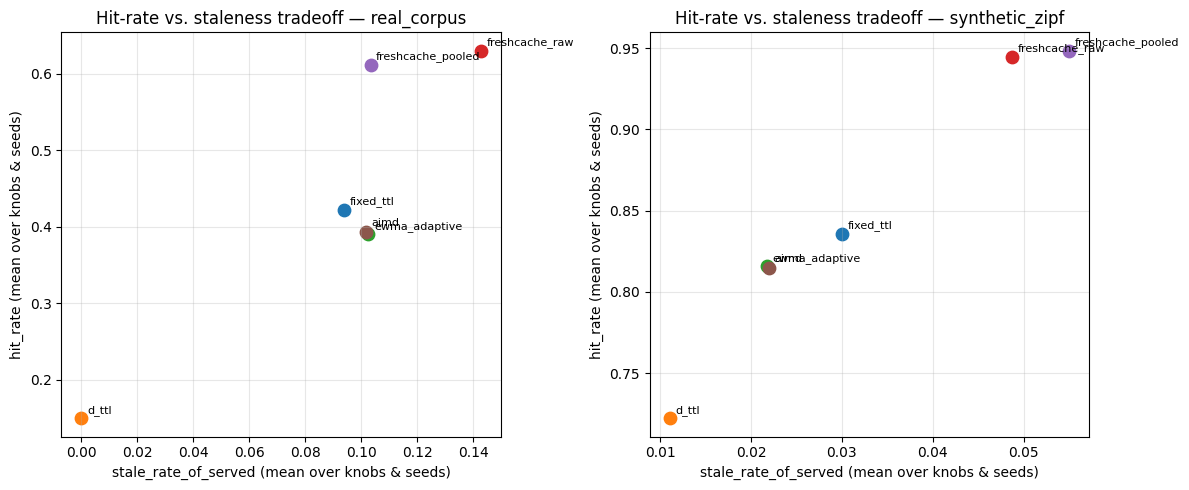

In [11]:
headline_rows = [r for r in rows if r["spot_check_rate"] == HEADLINE_RATE]

summary = defaultdict(lambda: defaultdict(list))
for r in headline_rows:
    summary[r["data_source"]][r["policy_name"]].append(r)

print(f"{'data_source':<16} {'policy':<18} {'n_cells':>8} {'hit_rate':>10} {'stale_rate':>11}")
print("-" * 68)
plot_points = defaultdict(list)
for data_source, policies in summary.items():
    for policy_name, prows in policies.items():
        hit_rates = [r["hit_rate"] for r in prows]
        stale_rates = [r["stale_rate_of_served"] for r in prows]
        mean_hit = sum(hit_rates) / len(hit_rates)
        mean_stale = sum(stale_rates) / len(stale_rates)
        n_knobs = len(set(json.dumps(r["knob_value"]) for r in prows))
        print(f"{data_source:<16} {policy_name:<18} {n_knobs:>8} {mean_hit:>10.3f} {mean_stale:>11.3f}")
        plot_points[data_source].append((policy_name, mean_hit, mean_stale))

fig, axes = plt.subplots(1, len(plot_points), figsize=(6 * len(plot_points), 5), squeeze=False)
for ax, (data_source, pts) in zip(axes[0], plot_points.items()):
    for policy_name, hit, stale in pts:
        ax.scatter(stale, hit, s=80, label=policy_name)
        ax.annotate(policy_name, (stale, hit), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("stale_rate_of_served (mean over knobs & seeds)")
    ax.set_ylabel("hit_rate (mean over knobs & seeds)")
    ax.set_title(f"Hit-rate vs. staleness tradeoff — {data_source}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()